In [1]:
from datetime import datetime
from getpass import getpass

admin_rdm_url = 'https://admin.test.rdm.example.com/'
rdm_url = 'https://test.rdm.example.com/'
idp_name_1 = 'GakuNin RDM IdP'
idp_username_1 = None
idp_password_1 = None
default_result_path = None
close_on_fail = False
transition_timeout = 60000
skip_failed_test = True
exclude_notebooks = []

# 機関ストレージ設定用パラメータ
target_organization = 'GakuNin RDM IdP'

# S3CompatSigV4 設定
s3_endpoint_url = None
s3_access_key = None
s3_secret_key = None
s3_bucket = #None


Server Side Encryption: False = NO
s3_server_side_encryption = False

# プロジェクト名プレフィックス
rdm_project_prefix = 'TEST-S3CompatSigV4-INST-{}'.format(datetime.now().strftime('%Y%m%d-%H%M%S'))

In [2]:
if idp_username_1 is None:
    idp_username_1 = input(prompt=f'Username for {idp_name_1}')
if idp_password_1 is None:
    idp_password_1 = getpass(prompt=f'Password for {idp_username_1}@{idp_name_1}')
(len(idp_username_1), len(idp_password_1))

(8, 20)

In [3]:
if s3_endpoint_url is None:
    s3_endpoint_url = input(prompt='S3 Endpoint URL')
if s3_access_key is None:
    s3_access_key = input(prompt='S3 Access Key')
if s3_secret_key is None:
    s3_secret_key = getpass(prompt='S3 Secret Key')
if s3_bucket is None:
    s3_bucket = input(prompt='S3 Bucket Name')
(len(s3_endpoint_url), len(s3_access_key), len(s3_secret_key), len(s3_bucket))

(33, 20, 40, 16)

In [4]:
import tempfile

work_dir = tempfile.mkdtemp()
if default_result_path is None:
    default_result_path = work_dir
work_dir

'/var/folders/q2/25q_lgpn37n0zq42mqtwz3p80000gn/T/tmpy6murnl3'

# GakuNinRDM 総合テスト [S3 Compatible Storage (SigV4) - 機関ストレージ]

- サブシステム名: 管理者 / ストレージ
- ページ/アドオン: 機関ストレージ (S3CompatSigV4)
- 機能分類: 機関ストレージ設定・ファイル操作確認
- シナリオ名: 管理者で機関ストレージにS3CompatSigV4を設定し、ユーザ画面でプロジェクト作成後ファイルアップロードを確認する
- 用意するテストデータ: URL一覧、アカウント(既存ユーザー1: GRDM)、S3互換ストレージのアクセス情報

In [5]:
import importlib
import pandas as pd

import scripts.playwright
importlib.reload(scripts.playwright)

from scripts.playwright import *
from scripts import grdm

await init_pw_context(close_on_fail=close_on_fail, last_path=default_result_path)

('20260217-144809',
 '/var/folders/q2/25q_lgpn37n0zq42mqtwz3p80000gn/T/tmp04q356ia')

## Part 1: 管理者画面での機関ストレージ設定

### GakuNin RDM管理者ページのURLを開く

管理者ページが表示されること

Start epoch: 1771307289.9880111 seconds


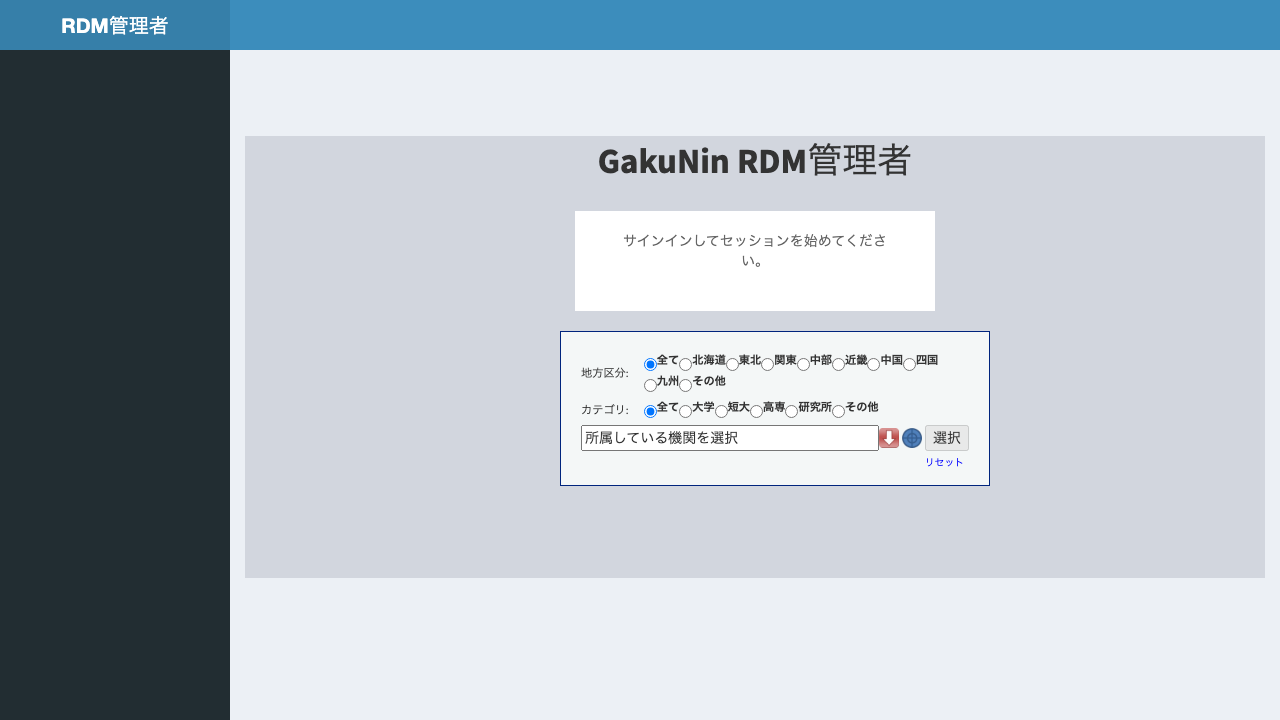

In [6]:
import time

async def _step(page):
    await page.goto(admin_rdm_url)

    await expect(page.locator('.login-logo')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

### ログイン情報を用いてGakuNin RDM管理者画面にログインする

(IdPに関するログイン情報が与えられた場合、)
GakuNin Embeded DSのプルダウンを展開し、IdPリストから指定されたIdPを選択する。その後、アカウントのID/Passwordを入力して「Login」ボタンを押下する。

(IdPが指定されていない場合、)
CASのログイン操作を実施する。

In [7]:
#   async def _debug(page):                                                                                         
#       # IdPリストの周辺HTMLを取得                                                                                 
#       html = await page.evaluate('() => document.getElementById("IdPList") ? document.getElementById("IdPList").outerHTML : document.body.innerHTML.substring(0, 5000)')
#       print(html)

#   await run_pw(_debug)

Start epoch: 1771307293.2325382 seconds


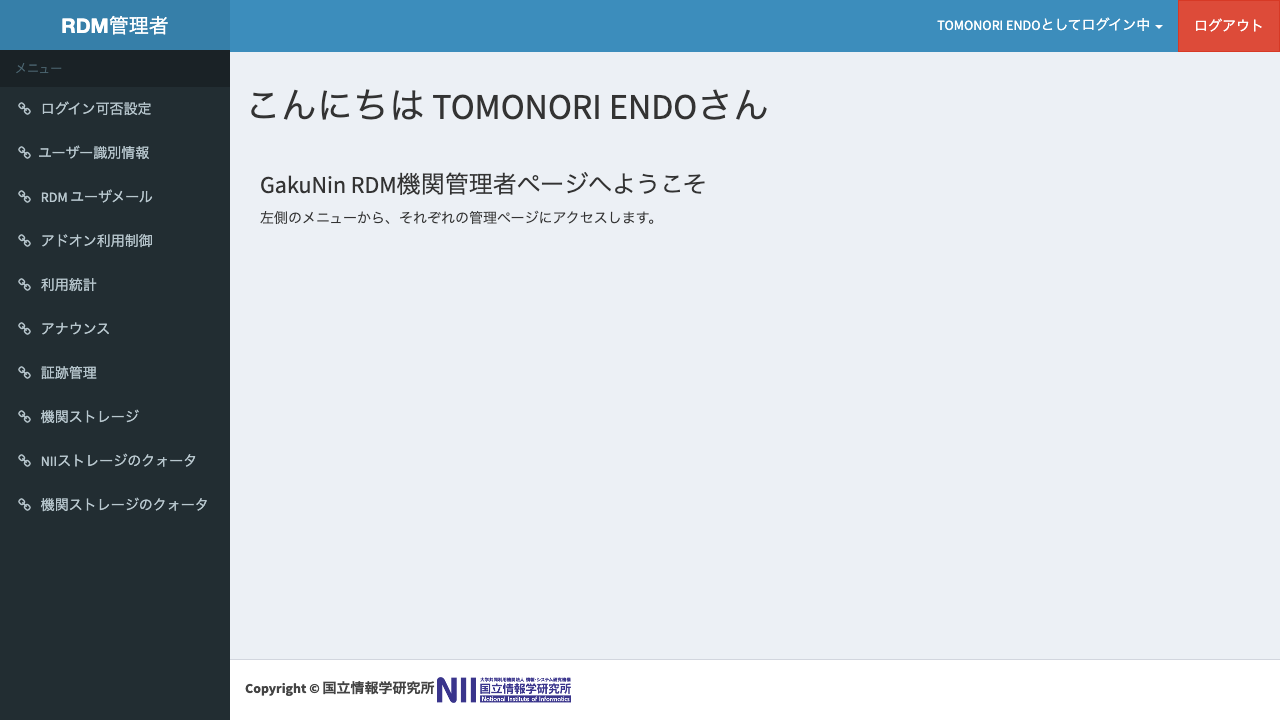

In [8]:
import scripts.grdm
importlib.reload(scripts.grdm)

async def _step(page):
    await scripts.grdm.login_as_admin(
        page, idp_name_1, idp_username_1, idp_password_1, transition_timeout=transition_timeout
    )

    await expect(page.locator('//*[contains(@class, "btn-danger") and contains(text(), "ログアウト")]')).to_be_enabled(timeout=transition_timeout)

await run_pw(_step)

### サイドメニューの「機関ストレージ」を選択する

機関ストレージの設定画面が表示されること

Start epoch: 1771307295.782968 seconds


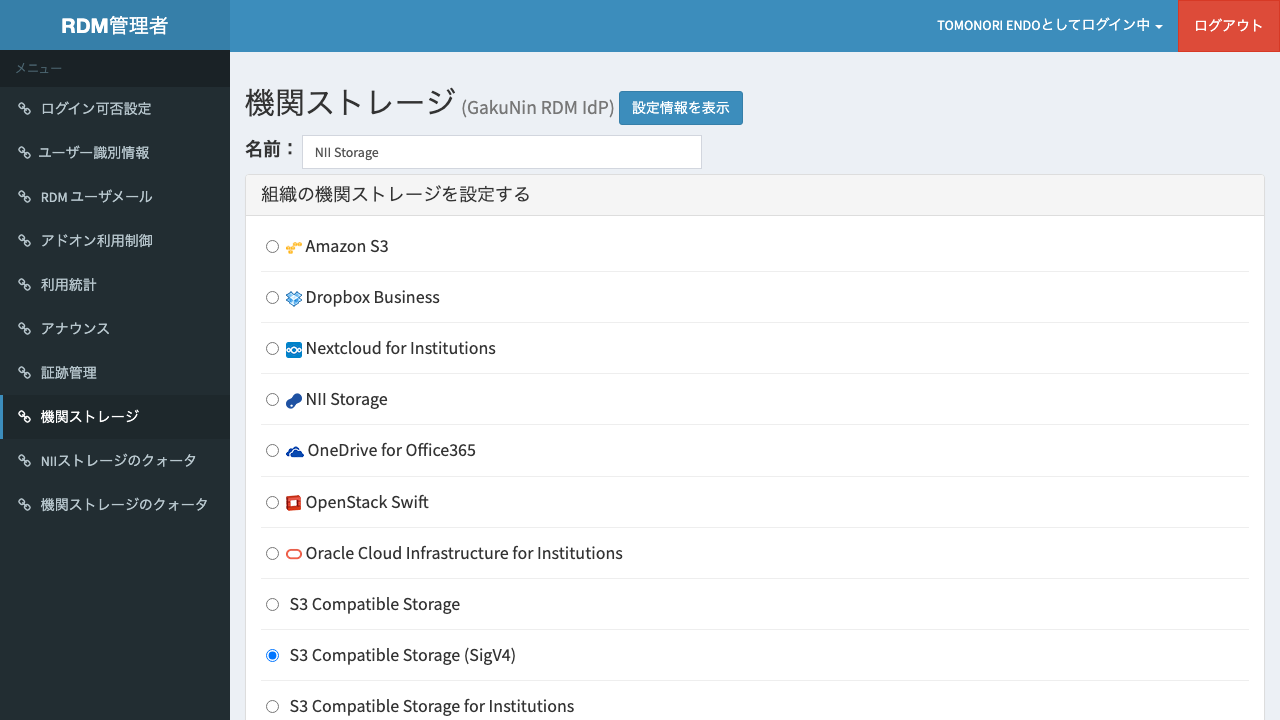

In [9]:
import traceback

async def _step(page):
    # サイドメニューの「機関ストレージ」をクリック（「機関ストレージのクォータ」と区別）
    await page.locator('//a[@href="/custom_storage_location/institutional_storage/"]').click()

    # 機関ストレージ設定画面が表示されること
    await expect(page.locator('//h2[contains(text(), "機関ストレージ")]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

### 機関のリストから対象機関を選択する

対象機関のInstitutional Storage設定画面が表示されること

In [10]:
async def _step(page):
    while True:
        link = page.locator(f'//a[text() = "{target_organization}"]')
        try:
            await expect(link).to_be_visible()
        except:
            traceback.print_exc()
            print('Search next page...')
            next_button = page.locator('//a[i[contains(@class, "fa-angle-right")]]')
            if await next_button.count() == 0 or await next_button.is_disabled():
                raise Exception(f'Organization "{target_organization}" not found in any page')
            await next_button.click()
            await expect(page.locator('//h2[contains(text(), "List of Institutions") or contains(text(), "機関のリスト")]')).to_be_visible(timeout=transition_timeout)
            continue
        await link.click()
        break

    await expect(page.locator('//h2[contains(text(), "Institutional Storage")]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)


### S3 Compatible Storage (SigV4) を選択する

S3 Compatible Storage (SigV4) のラジオボタンが選択されること

Start epoch: 1771307444.0033689 seconds


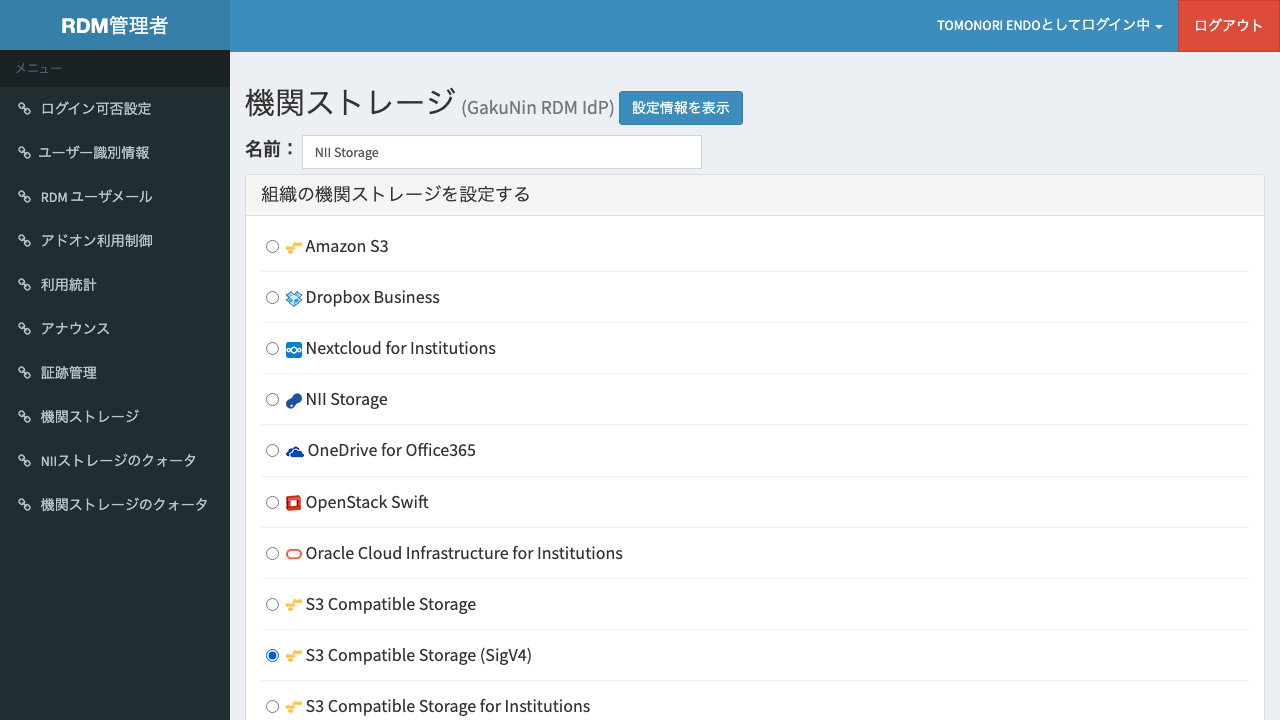

In [11]:
async def _step(page):
    # S3CompatSigV4 のラジオボタンを選択
    await page.locator('//input[@type="radio" and @value="s3compatsigv4"]').click()

await run_pw(_step)

### 「Save」ボタンをクリックし、確認ダイアログで確認文字列を入力して「Change」をクリックする

機関ストレージ変更の確認ダイアログが表示される。表示された確認文字列を入力し、「Change」をクリックするとS3CompatSigV4の設定モーダルが表示されること。

※ 確認文字列はランダムに生成されるため、画面を確認して手入力する。

Start epoch: 1771307445.8161259 seconds
Confirmation string: Jemison


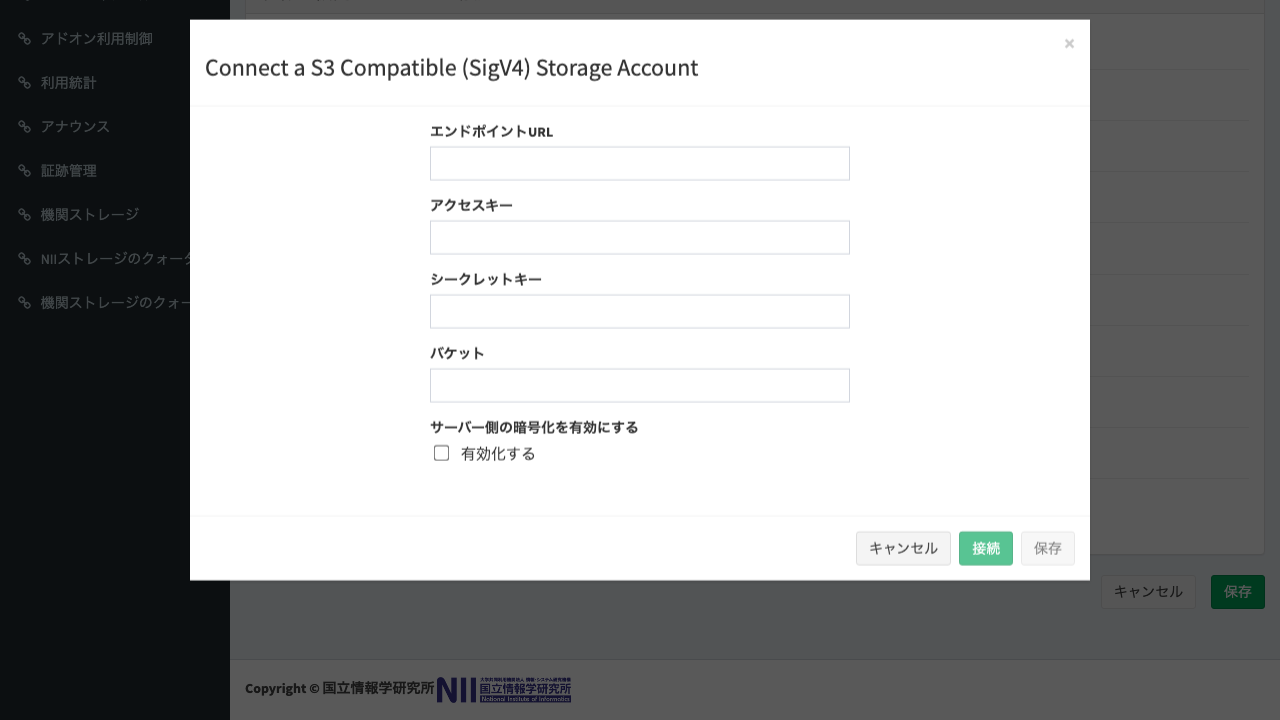

In [12]:
async def _step(page):
    # Save(保存) ボタンをクリック（画面下部にあるためスクロール）
    save_btn = page.locator('//button[contains(@class, "btn-success") and contains(@class, "next-btn")]')
    await save_btn.scroll_into_view_if_needed()
    await save_btn.click()

    # 確認ダイアログが表示される
    await expect(page.locator('#bbConfirmText')).to_be_visible(timeout=transition_timeout)

    # 確認文字列を取得
    confirm_strong = page.locator('//div[contains(@class, "bootbox-body")]//strong')
    confirmation_string = await confirm_strong.text_content()
    print(f'Confirmation string: {confirmation_string}')

    # 確認文字列を入力
    await page.locator('#bbConfirmText').fill(confirmation_string)

    # 「変更」ボタンをクリック（btn-danger）
    await page.locator('//div[contains(@class, "modal") and contains(@class, "bootbox")]//button[contains(@class, "btn-danger")]').click()

    # S3CompatSigV4 モーダルが表示されるのを待つ
    await expect(page.locator('#s3compatsigv4_modal')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

### Endpoint URL、Access Key、Secret Key、Bucketを入力し、Server Side EncryptionをNOに設定する

各項目が正しく入力されること

In [ ]:
import asyncio

async def _step(page):
    # Endpoint URL を入力
    await page.locator('#s3compatsigv4_endpoint_url').fill(s3_endpoint_url)

    # Access Key を入力
    await page.locator('#s3compatsigv4_access_key').fill(s3_access_key)

    # Secret Key を入力
    await page.locator('#s3compatsigv4_secret_key').fill(s3_secret_key)

    # Bucket を入力
    await page.locator('#s3compatsigv4_bucket').fill(s3_bucket)

    # Server Side Encryption のチェックボックス
    sse_checkbox = page.locator('#s3compatsigv4_server_side_encryption')
    is_checked = await sse_checkbox.is_checked()
    if s3_server_side_encryption and not is_checked:
        await sse_checkbox.click()
    elif not s3_server_side_encryption and is_checked:
        await sse_checkbox.click()

    # keyupイベントを発火させてバリデーションをトリガー
    await page.evaluate('() => { document.querySelectorAll("#s3compatsigv4_modal input").forEach(el => el.dispatchEvent(new Event("keyup", { bubbles: true }))); }')

    # 入力後少し待つ
    await asyncio.sleep(1)

await run_pw(_step)

### 「Connect」ボタンをクリックして接続テストを行う

接続テストが成功すること

In [ ]:
async def _step(page):
    # Connect ボタンをクリック
    connect_btn = page.locator('#s3compatsigv4_connect')
    await expect(connect_btn).to_be_enabled(timeout=transition_timeout)
    await connect_btn.click()

    # Save ボタンが有効になるのを待つ（接続成功の証）
    save_btn = page.locator('#s3compatsigv4_save')
    await expect(save_btn).to_be_enabled(timeout=transition_timeout)

await run_pw(_step)

### 「Save」ボタンをクリックして設定を保存する

機関ストレージの設定が保存されること

Start epoch: 1771307450.0934741 seconds


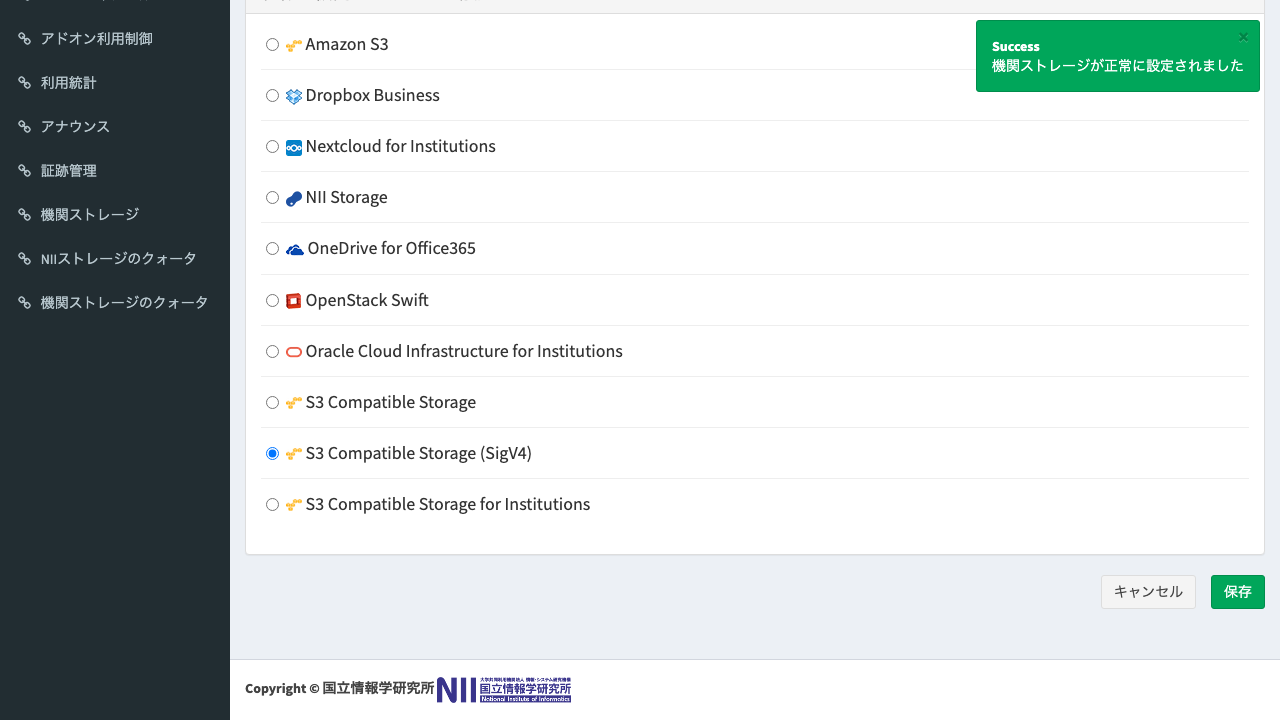

In [15]:
async def _step(page):
    # Save ボタンをクリック
    save_btn = page.locator('#s3compatsigv4_save')
    await save_btn.click()

    # モーダルが閉じるのを待つ
    await expect(page.locator('#s3compatsigv4_modal')).to_be_hidden(timeout=transition_timeout)

    # 少し待って設定が反映されるのを確認
    await asyncio.sleep(2)

await run_pw(_step)

### 管理者画面からログアウトする

ログアウトが完了すること

Start epoch: 1771307454.066821 seconds


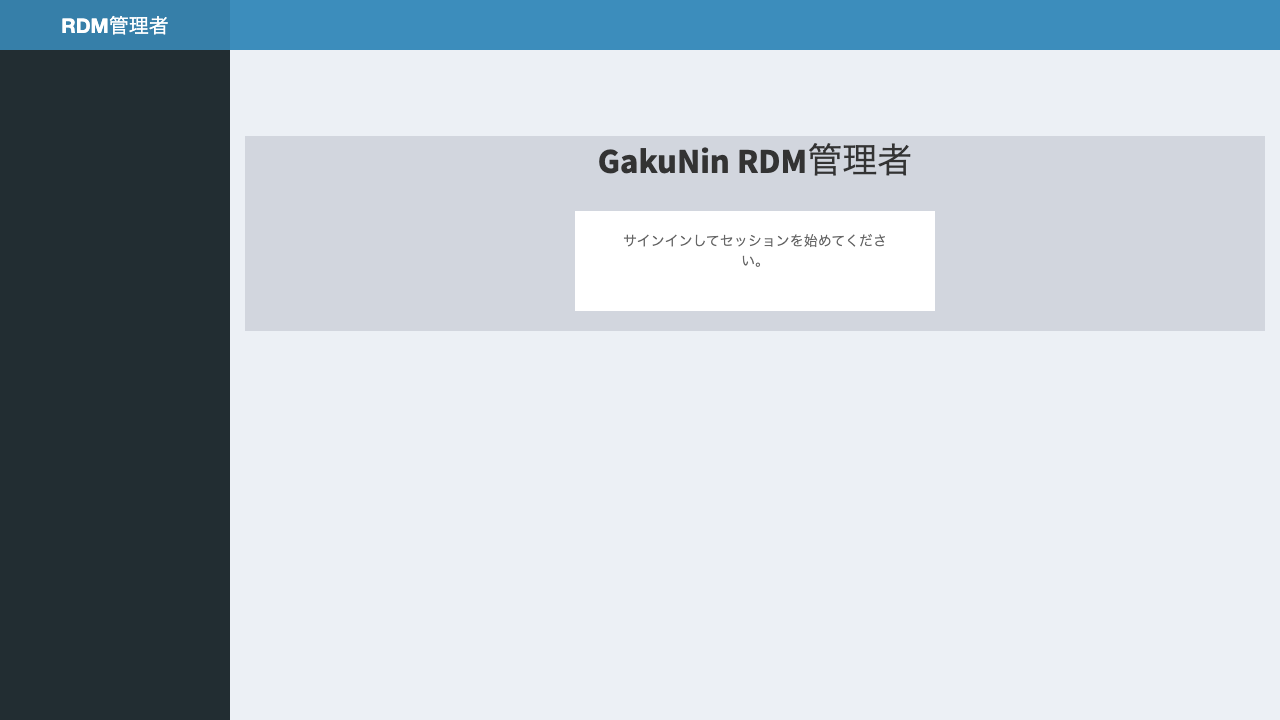

In [16]:
async def _step(page):
    await page.locator('//*[contains(@class, "btn-danger") and contains(text(), "ログアウト")]').click()

    await expect(page.locator('.login-logo')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## Part 2: ユーザ画面でのプロジェクト作成とファイルアップロード

### GRDMトップページを表示する

GRDMトップページが表示されること

In [17]:
async def _step(page):
    await page.goto(rdm_url)

    # 同意する ボタンまたはサインインボタンが現れるまで待つ
    consent_button = page.locator('//button[text() = "同意する"]')
    sign_in_button = page.locator('//button[@data-test-sign-in-button]')
    dashboard = page.locator('//*[@data-test-create-project-modal-button]')

    await expect(consent_button.or_(sign_in_button).or_(dashboard)).to_be_visible(timeout=transition_timeout)

    if await consent_button.is_visible():
        await consent_button.click()
        await expect(sign_in_button.or_(dashboard)).to_be_visible(timeout=transition_timeout)

await run_pw(_step)


### ログイン情報を用いてGakuNin RDMにログインする

(IdPに関するログイン情報が与えられた場合、)
GakuNin Embeded DSのプルダウンを展開し、IdPリストから指定されたIdPを選択する。その後、アカウントのID/Passwordを入力して「Login」ボタンを押下する。

(IdPが指定されていない場合、)
CASのログイン操作を実施する。

Start epoch: 1771307533.733966 seconds


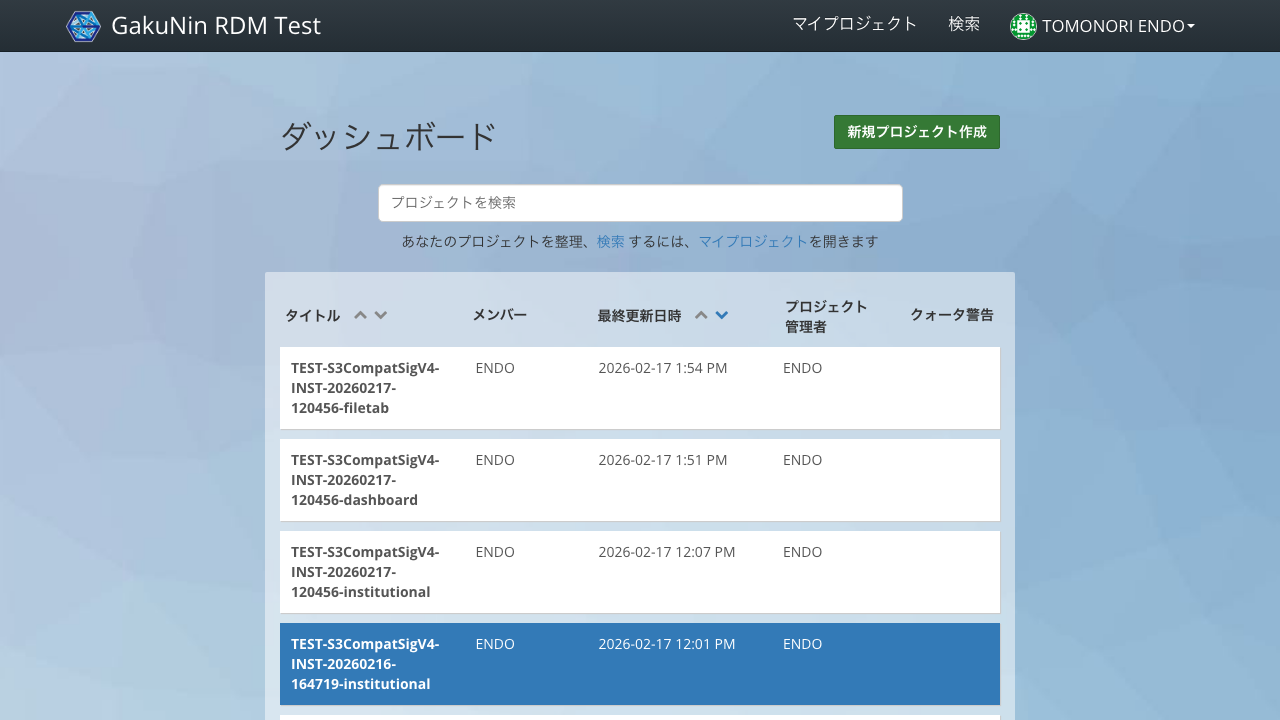

In [18]:
import scripts.grdm
importlib.reload(scripts.grdm)

async def _step(page):
    await scripts.grdm.login(
        page, idp_name_1, idp_username_1, idp_password_1, transition_timeout=transition_timeout
    )

    await expect(page.locator('//*[text() = "プロジェクト管理者"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

### プロジェクトを作成する

「{rdm_project_prefix}-institutional」プロジェクトが作成されること

Start epoch: 1771307542.497956 seconds


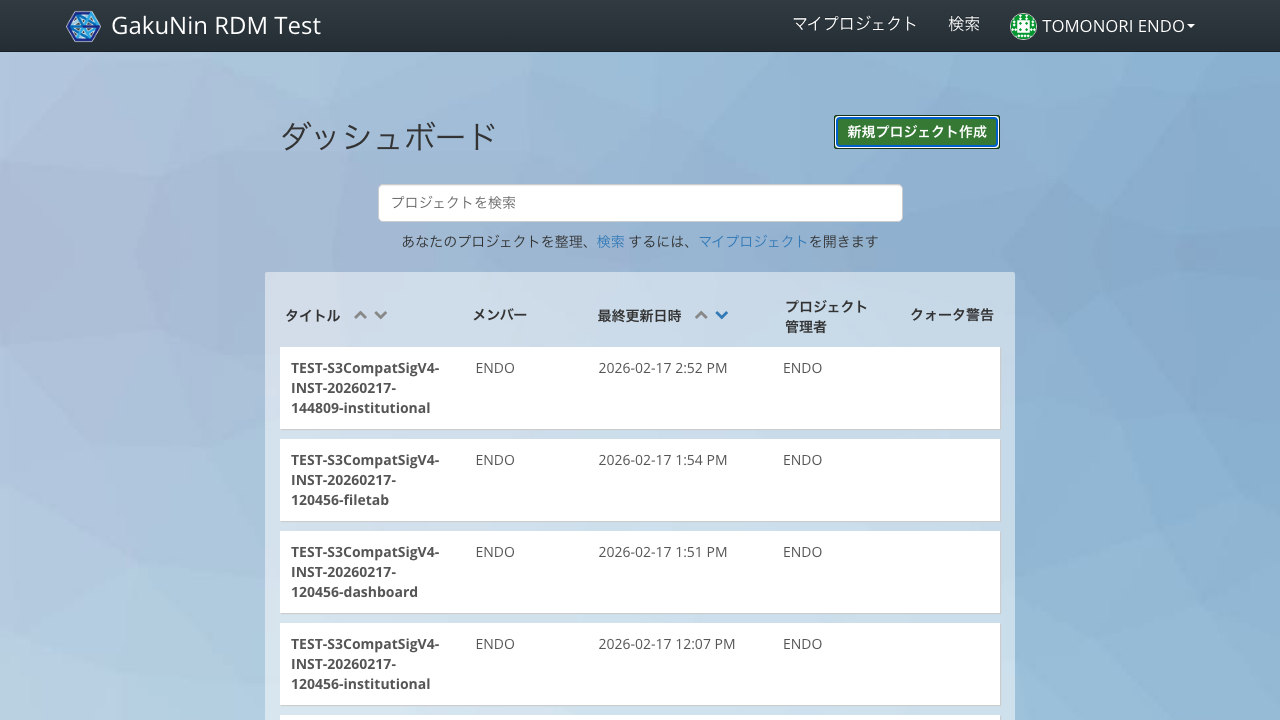

In [19]:
import scripts.grdm
importlib.reload(scripts.grdm)

rdm_project_name = f'{rdm_project_prefix}-institutional'

async def _step(page):
    await expect(page.locator('//*[@data-test-create-project-modal-button]')).to_have_count(1)

    await scripts.grdm.ensure_project_exists(page, rdm_project_name, transition_timeout)

await run_pw(_step)

### ダッシュボードのプロジェクト一覧から作成したプロジェクトをクリックする

プロジェクトダッシュボードが表示されること

Start epoch: 1771307551.4801128 seconds


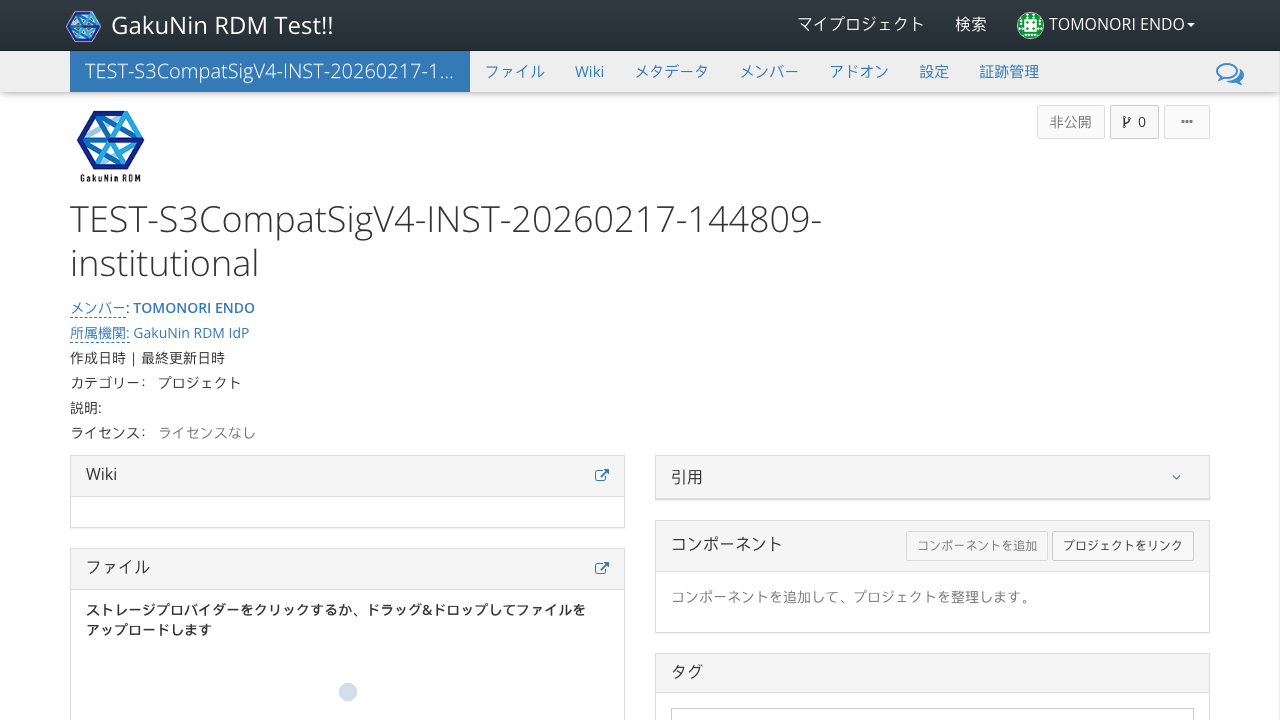

In [20]:
async def _step(page):
    await page.locator(f'//*[@data-test-dashboard-item-title and text()="{rdm_project_name}"]').click()

    # プロジェクトダッシュボードのナビタブが表示されること
    await expect(page.locator('#projectNavFiles')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

### 「ファイル」タブをクリックする

ファイルタブが表示されること。NII Storageの代わりにS3CompatSigV4の機関ストレージが表示されること。

Start epoch: 1771307571.574021 seconds


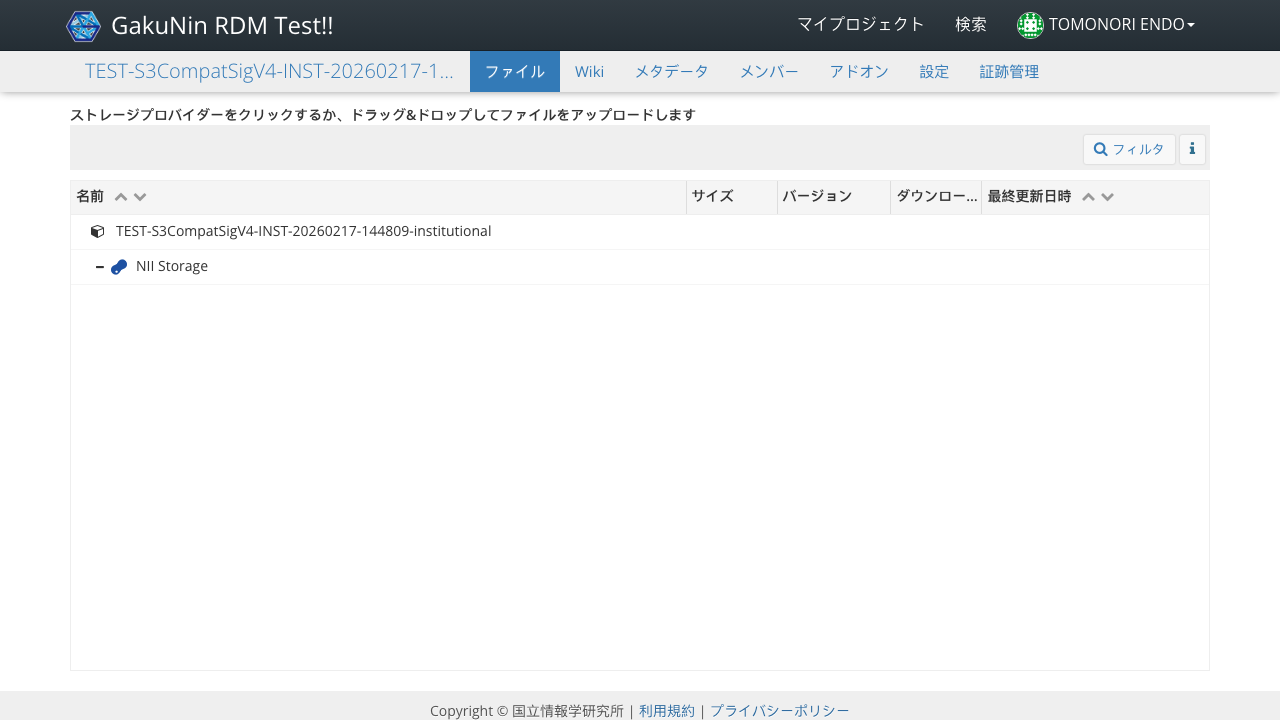

In [21]:
async def _step(page):
    await page.locator('#projectNavFiles a').click()

    await expect(page.locator('//*[@id = "treeGrid"]')).to_be_visible(timeout=transition_timeout)

    # 少し待ってファイルツリーが読み込まれるのを確認
    await asyncio.sleep(3)

await run_pw(_step)

### テスト用ファイルを作成する

テスト用のファイルが作成されること

In [22]:
import os

test_file_name = 'test_institutional_storage.txt'
test_file_path = os.path.join(work_dir, test_file_name)
with open(test_file_path, 'w') as f:
    f.write(f'Institutional Storage Test - S3CompatSigV4\n')
    f.write(f'Created at: {datetime.now().isoformat()}\n')
    f.write(f'Bucket: {s3_bucket}\n')
    f.write(f'Endpoint: {s3_endpoint_url}\n')

print(f'Test file created: {test_file_path}')

Test file created: /var/folders/q2/25q_lgpn37n0zq42mqtwz3p80000gn/T/tmpy6murnl3/test_institutional_storage.txt


### ファイルをアップロードする

ファイルがアップロードされ、ファイル一覧に表示されること

Start epoch: 1771307575.394974 seconds


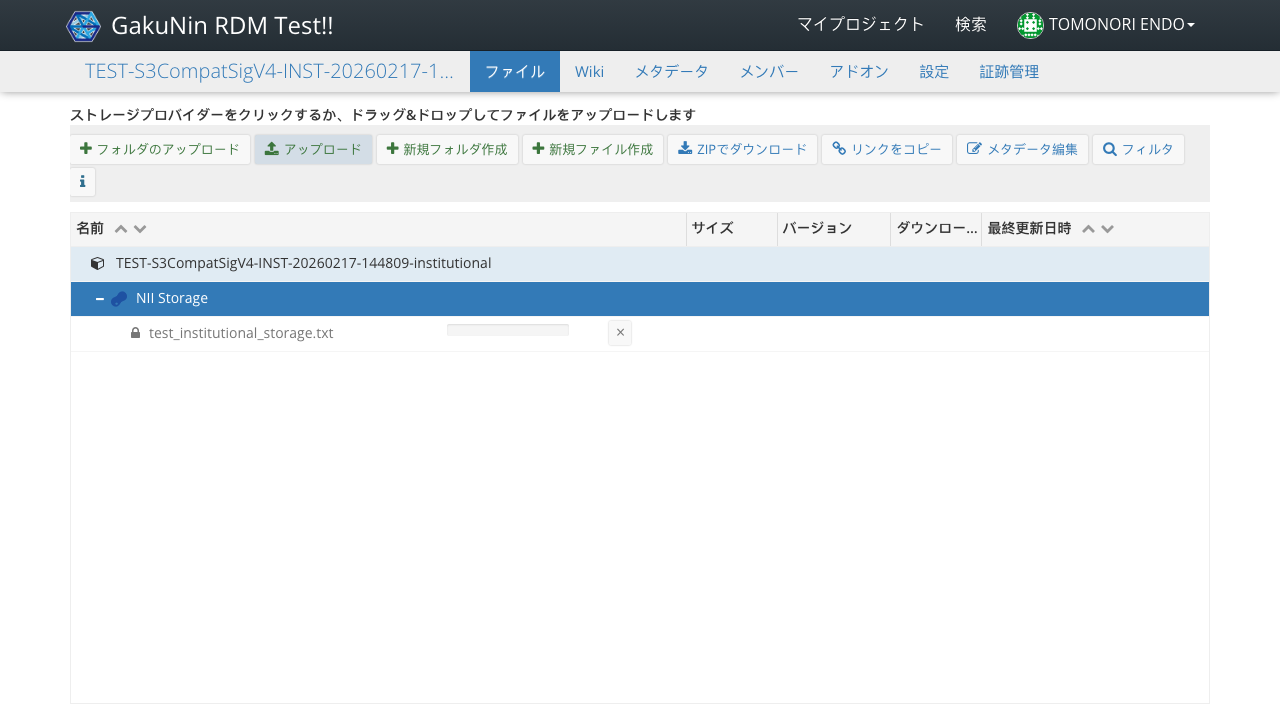

In [23]:
async def _step(page):
    # minIOストレージプロバイダをクリックして開く
    await page.locator('//*[contains(text(), "NII Storage")]').click()
    await asyncio.sleep(2)

    # アップロードボタンが表示されるのを待つ
    upload_btn = page.locator('//i[contains(@class, "fa-upload")]/../*[text() = "アップロード"]')
    await expect(upload_btn).to_be_visible(timeout=transition_timeout)

    await scripts.grdm.upload_file(page, test_file_path)

    # アップロードしたファイルが表示されるのを確認
    await expect(page.locator(f'//*[contains(text(), "{test_file_name}")]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

### アップロードしたファイルをクリックして内容を確認する

ファイルの内容が表示されること

Start epoch: 1771311147.9335601 seconds


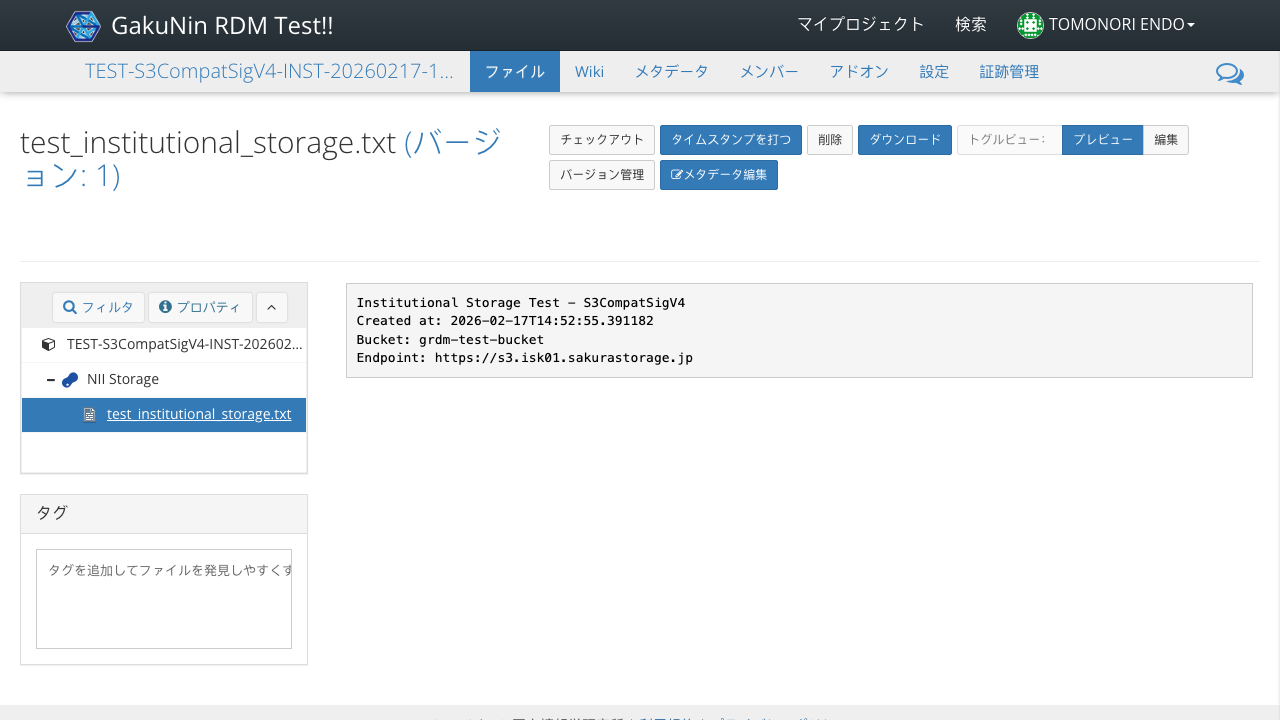

In [35]:
async def _step(page):                                                                                          
    if 'files' in page.url and test_file_name in await page.title():
        pass                                                                                                    
    else:                                                                                                     
        file_link = page.locator(f'//*[@id="tb-tbody"]//span[text()="{test_file_name}"]').first
        await file_link.click()
        await asyncio.sleep(5)

    # ファイル詳細ページが表示されていることを確認
    await expect(page.get_by_text("(バージョン: 1)")).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

### プロジェクトを削除する

プロジェクトが削除されること

In [ ]:
async def _step(page):
    await scripts.grdm.delete_project(page)

    await expect(page.locator('//*[text() = "プロジェクト管理者"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## Part 3: 後処理

### 「ファイル基本操作」テストの実施（機関ストレージ利用時）

テスト「テスト手順-ストレージ共通-ファイル基本操作」を機関ストレージ設定下でプロジェクトダッシュボードにて実施する。

In [36]:
from datetime import datetime
import os
import papermill as pm
import traceback
from scripts.papermillHelpers import gen_run_notebook

def make_result_dir(base_path):
    result_dir = os.path.join(base_path, 'notebooks')
    os.makedirs(result_dir, exist_ok=True)
    return result_dir

result_dir = make_result_dir(default_result_path)

run_notebook = gen_run_notebook(
    result_dir,
    transition_timeout,
    dict(
        rdm_url=rdm_url,
        idp_name_1=idp_name_1,
        idp_username_1=idp_username_1,
        idp_password_1=idp_password_1,
    ),
    skip_failed_test,
    exclude_notebooks,
)

result_notebooks = []
result_dir

'/var/folders/q2/25q_lgpn37n0zq42mqtwz3p80000gn/T/tmpy6murnl3/notebooks'

### プロジェクトダッシュボードでの「ファイル基本操作」テストの実施

テスト「テスト手順-ストレージ共通-ファイル基本操作」をプロジェクトダッシュボードで実施する。

In [38]:
result_notebooks.append(run_notebook(
    'テスト手順-ストレージ共通-ファイル基本操作.ipynb',
    dict(
        enable_52gb_file_upload=False,
        target_storage_name='NII Storage',
        target_file_view='project-dashboard',
        rdm_project_name=f'{rdm_project_prefix}-dashboard',
    ),
))
result_notebooks

Passed unknown parameter: enable_52gb_file_upload


Executing:   0%|          | 0/119 [00:00<?, ?cell/s]

0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.


失敗しました。テストは続行します...


Traceback (most recent call last):
  File "/Users/endo.tomonori/Desktop/git/tishin-endou/RDM-e2e-test-nb/scripts/papermillHelpers.py", line 50, in run_notebook
    pm.execute_notebook(base_notebook, result_notebook, parameters=params)
  File "/Users/endo.tomonori/anaconda3/lib/python3.11/site-packages/papermill/execute.py", line 131, in execute_notebook
    raise_for_execution_errors(nb, output_path)
  File "/Users/endo.tomonori/anaconda3/lib/python3.11/site-packages/papermill/execute.py", line 251, in raise_for_execution_errors
    raise error
papermill.exceptions.PapermillExecutionError: 
---------------------------------------------------------------------------
Exception encountered at "In [23]":
---------------------------------------------------------------------------
AssertionError                            Traceback (most recent call last)
Cell In[23], line 12
      9     await expect(grdm.get_select_file_title_locator(page, filename)).to_have_count(0, timeout=transition_time

['/var/folders/q2/25q_lgpn37n0zq42mqtwz3p80000gn/T/tmpy6murnl3/notebooks/テスト手順-ストレージ共通-ファイル基本操作.ipynb',
 '/var/folders/q2/25q_lgpn37n0zq42mqtwz3p80000gn/T/tmpy6murnl3/notebooks/テスト手順-ストレージ共通-ファイル基本操作.ipynb']

### ファイルタブでの「ファイル基本操作」テストの実施

テスト「テスト手順-ストレージ共通-ファイル基本操作」をファイルタブで実施する。

In [39]:
result_notebooks.append(run_notebook(
    'テスト手順-ストレージ共通-ファイル基本操作.ipynb',
    dict(
        enable_52gb_file_upload=False,
        target_storage_name='NII Storage',
        target_file_view='file-tab',
        rdm_project_name=f'{rdm_project_prefix}-filetab',
    ),
    '-file-tab',
))
result_notebooks

Passed unknown parameter: enable_52gb_file_upload


Executing:   0%|          | 0/119 [00:00<?, ?cell/s]

0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.


['/var/folders/q2/25q_lgpn37n0zq42mqtwz3p80000gn/T/tmpy6murnl3/notebooks/テスト手順-ストレージ共通-ファイル基本操作.ipynb',
 '/var/folders/q2/25q_lgpn37n0zq42mqtwz3p80000gn/T/tmpy6murnl3/notebooks/テスト手順-ストレージ共通-ファイル基本操作.ipynb',
 '/var/folders/q2/25q_lgpn37n0zq42mqtwz3p80000gn/T/tmpy6murnl3/notebooks/テスト手順-ストレージ共通-ファイル基本操作-file-tab.ipynb']

終了処理を実施。

In [ ]:
await finish_pw_context()

In [ ]:
!rm -fr {work_dir}